# Carregamento dos Dados e Importações

## Importando as Bibliotecas

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/heart.csv")

In [13]:
linhas, colunas = df.shape

print(f"O conjunto de dados possui {linhas} linhas e {colunas} colunas.")

O conjunto de dados possui 918 linhas e 12 colunas.


In [6]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


### Dicionário de Dados

- **Age:** idade do paciente em anos.
- **Sex:** sexo do paciente, podendo ser masculino (M) ou feminino (F).
- **ChestPainType:** tipo de dor no peito apresentada pelo paciente.
- **RestingBP:** pressão arterial em repouso, medida em mmHg.
- **Cholesterol:** nível de colesterol no sangue, medido em mg/dL.
- **FastingBS:** indica se a glicemia em jejum é maior que 120 mg/dL (1 = sim, 0 = não).
- **RestingECG:** resultado do eletrocardiograma realizado em repouso.
- **MaxHR:** frequência cardíaca máxima atingida pelo paciente.
- **ExerciseAngina:** indica se o paciente apresentou angina durante exercício físico (Y = sim, N = não).
- **Oldpeak:** medida da depressão do segmento ST provocada pelo exercício em relação ao repouso.
- **ST_Slope:** inclinação do segmento ST durante o pico do exercício.
- **HeartDisease:** variável alvo do projeto, indicando a presença (1) ou ausência (0) de doença cardíaca.

> A variável **HeartDisease** será utilizada como variável alvo, enquanto as demais serão empregadas como variáveis preditoras para o treinamento dos modelos de Machine Learning.

# Análise Exploratória dos Dados (EDA)

## Distribuição da Idade

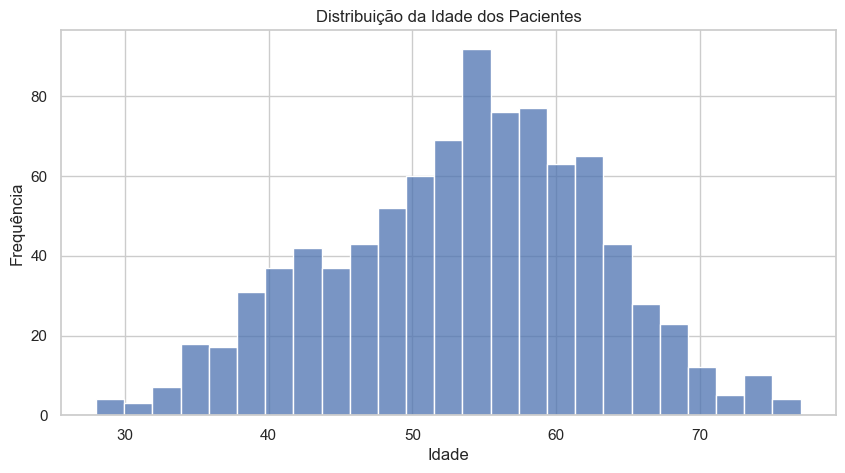

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=25, kde=False)

plt.title("Distribuição da Idade dos Pacientes")
plt.xlabel("Idade")
plt.ylabel("Frequência")

plt.show()

## Distribuição do Colesterol

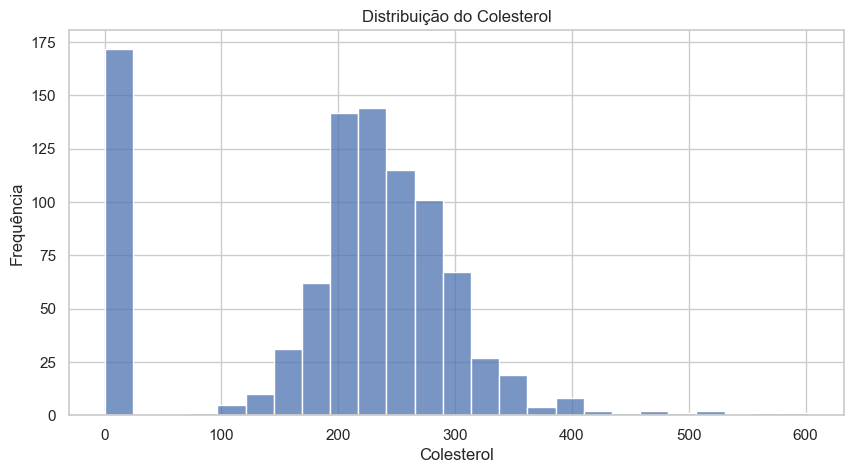

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df["Cholesterol"], bins=25, kde=False)

plt.title("Distribuição do Colesterol")
plt.xlabel("Colesterol")
plt.ylabel("Frequência")

plt.show()

Foi observada uma quantidade considerável de pacientes com colesterol igual a zero. Como esse valor não é compatível com a realidade, é provável que represente dados ausentes ou erros de registro. Por enquanto, esses dados serão mantidos e avaliados posteriormente durante o pré-processamento. 

## Distribuição da Frequência Cardíaca Máxima

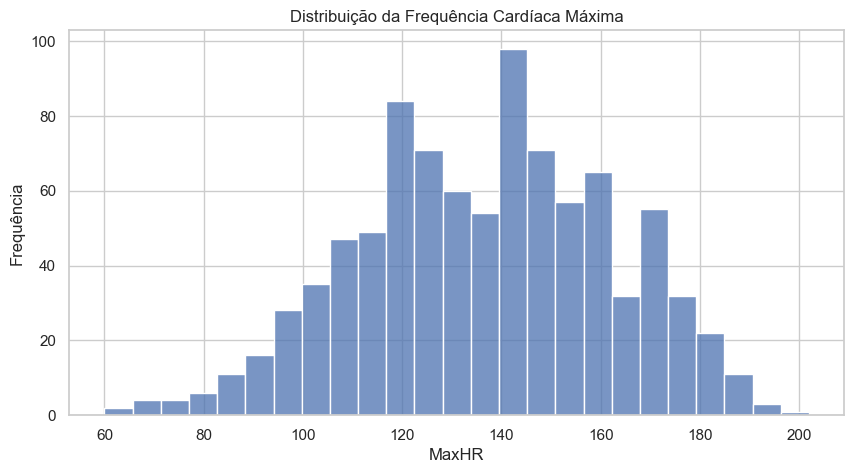

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df["MaxHR"], bins=25, kde=False)

plt.title("Distribuição da Frequência Cardíaca Máxima")
plt.xlabel("MaxHR")
plt.ylabel("Frequência")

plt.show()

## Distribuição da Variável Alvo (HeartDisease)

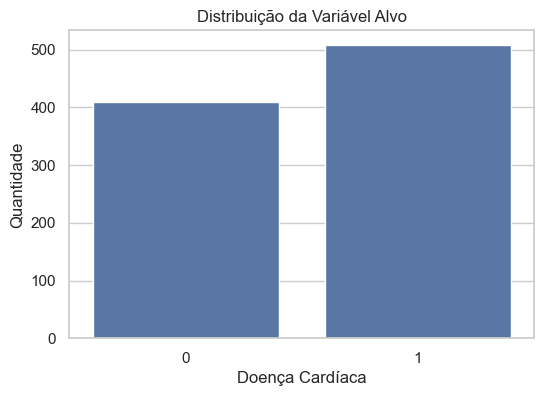

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="HeartDisease")

plt.title("Distribuição da Variável Alvo")
plt.xlabel("Doença Cardíaca")
plt.ylabel("Quantidade")

plt.show()

## Distribuição entre Sexo × Doença Cardíaca

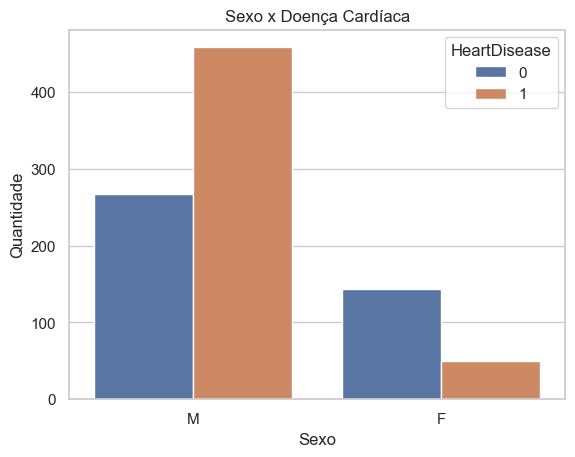

In [18]:
sns.countplot(data=df, x="Sex", hue="HeartDisease")

plt.title("Sexo x Doença Cardíaca")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")

plt.show()

## Distribuição entre Dor no Peito × Doença Cardíaca

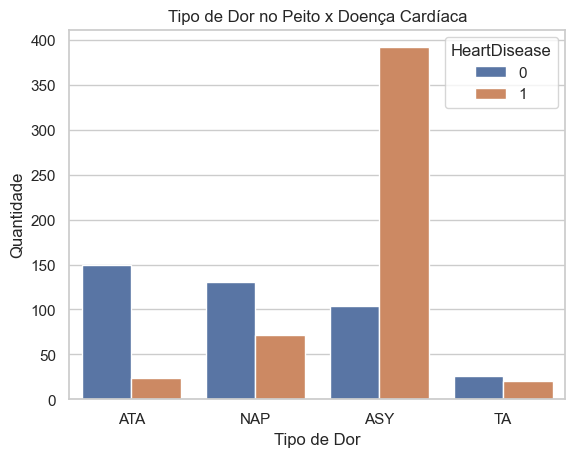

In [19]:
sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")

plt.title("Tipo de Dor no Peito x Doença Cardíaca")
plt.xlabel("Tipo de Dor")
plt.ylabel("Quantidade")

plt.show()

**Glossário:**

- **ATA (Angina Atípica):** Dor no peito com características parciais de angina
- **NAP (Dor Não Anginosa):** Dor no peito sem relação com problemas cardíacos
- **ASY (Assintomático):** Ausência de dor ou sintomas relacionados ao coração
- **TA (Angina Típica):** Dor no peito associada à redução do fluxo sanguíneo para o coração

## Açúcar no Sangue × Doença Cardíaca

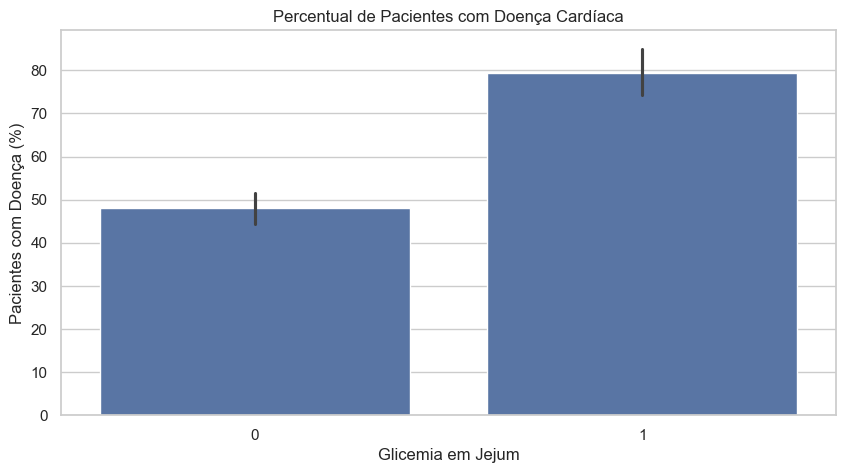

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="FastingBS",
    y="HeartDisease",
    estimator=lambda x: x.mean() * 100
)

plt.title("Percentual de Pacientes com Doença Cardíaca")
plt.xlabel("Glicemia em Jejum")
plt.ylabel("Pacientes com Doença (%)")

plt.show()

**Contexto:** A glicemia de jejum (FastingBS) mede o nível de açúcar no sangue após um período sem consumir alimentos ou bebidas (exceto água), geralmente entre 8 e 14 horas

## Angina × Doença Cardíaca

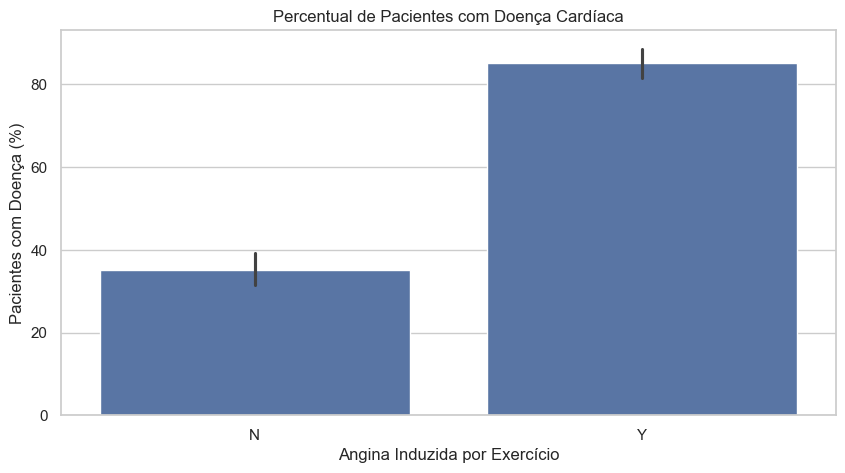

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="ExerciseAngina",
    y="HeartDisease",
    estimator=lambda x: x.mean() * 100
)

plt.title("Percentual de Pacientes com Doença Cardíaca")
plt.xlabel("Angina Induzida por Exercício")
plt.ylabel("Pacientes com Doença (%)")

plt.show()

**Contexto:** A angina é um tipo de dor ou desconforto no peito que ocorre quando o músculo do coração (miocárdio) não recebe oxigênio suficiente. Geralmente é causada pelo estreitamento das artérias coronárias (aterosclerose) e serve como um sinal de alerta para a doença arterial coronariana e risco de infarto

## Heatmap de Correlação entre as Variáveis

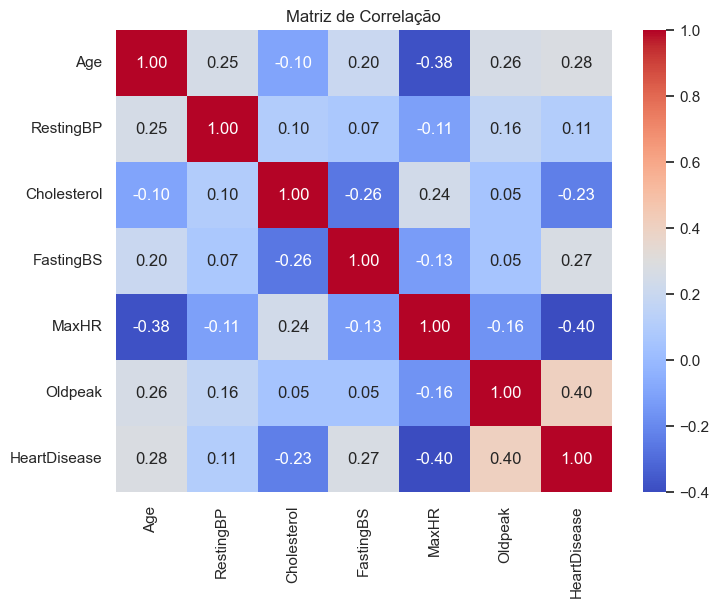

In [22]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()